# convolve-rs vs RACS-tools benchmark

Generates dummy FITS images, runs **convolvers** (Rust) and **beamcon_2D**
(RACS-tools, Python) to a fixed target beam, and measures wall time, CPU usage
(mean cores busy) and peak RSS. RACS-tools is tested with both its `thread`
and `process` executors.

Outputs (data, smoothed FITS, plots) land under `bench_out/` and are gitignored.

Run all cells: `Cell -> Run All`, or
`uv run --extra benchmark jupyter nbconvert --execute --to notebook --inplace scripts/benchmark.ipynb`.

In [1]:
import platform
import re
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits

import make_dummy_fits as mdf  # sibling script, reused for data generation

# Absolute paths to the two binaries under test.
BEAMCON = "/Users/alec.thomson/miniforge3/envs/racs-tools/bin/beamcon_2D"
CONVOLVERS = "/Users/alec.thomson/.cargo/bin/convolvers"

# Fixed circular target beam, larger than every generated input beam (<=15").
TARGET = ["--bmaj", "20", "--bmin", "20", "--bpa", "0"]

WORK = Path("bench_out")
IS_MAC = platform.system() == "Darwin"

# Display labels -> executor flag (None = the Rust binary).
RUNNERS = {
    "convolvers": None,
    "beamcon-thread": "thread",
    "beamcon-process": "process",
}

## Helpers

In [2]:
def run_timed(cmd: list[str]) -> dict:
    """Run cmd under /usr/bin/time -l; return wall/user/sys/cpu/cores/rss_mb."""
    t0 = time.perf_counter()
    proc = subprocess.run(["/usr/bin/time", "-l", *cmd],
                          capture_output=True, text=True)
    wall = time.perf_counter() - t0
    if proc.returncode != 0:
        raise RuntimeError(proc.stdout + proc.stderr)

    err = proc.stderr
    user = float(re.search(r"([\d.]+)\s+user", err).group(1))
    sys_ = float(re.search(r"([\d.]+)\s+sys", err).group(1))
    m = re.search(r"(\d+)\s+maximum resident set size", err)
    rss = int(m.group(1)) if m else 0
    rss_mb = rss / 1e6 if IS_MAC else rss / 1e3  # macOS bytes, GNU KB
    cpu = user + sys_
    return {"wall": wall, "cpu_pct": 100 * cpu / wall,
            "cores": cpu / wall, "rss_mb": rss_mb}


def gen_data(data: Path, n: int, size: int, sources: int = 500, seed: int = 1234):
    """Write n dummy FITS images via make_dummy_fits helpers; return paths."""
    data.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)
    pix_deg = 2.5 / 3600.0
    for i in range(n):
        bmaj = rng.uniform(10.0, 15.0) / 3600.0
        bmin = bmaj * rng.uniform(0.1, 0.9)
        bpa = rng.uniform(0.0, 180.0)
        hdr = mdf.make_header(size, pix_deg, bmaj, bmin, bpa)
        arr = mdf.make_data(size, sources, rng)
        fits.writeto(data / f"dummy_{i:04d}.fits", arr, hdr, overwrite=True)
    return sorted(str(p) for p in data.glob("*.fits"))


def build_cmd(label: str, infiles: list[str], outdir: Path) -> list[str]:
    outdir.mkdir(parents=True, exist_ok=True)
    executor = RUNNERS[label]
    if executor is None:
        return [CONVOLVERS, "2d", "-o", str(outdir), *TARGET, *infiles]
    return [BEAMCON, "-o", str(outdir), "--executor", executor, *TARGET, *infiles]


def max_abs_diff(dir_a: Path, dir_b: Path) -> float:
    """Largest |Δ| over matched smoothed images between two output dirs."""
    worst = 0.0
    for fa in sorted(dir_a.glob("*.sm.fits")):
        fb = dir_b / fa.name
        if not fb.exists():
            continue
        a = fits.getdata(fa).squeeze().astype(np.float64)
        b = fits.getdata(fb).squeeze().astype(np.float64)
        worst = max(worst, float(np.nanmax(np.abs(a - b))))
    return worst


def run_case(tag: str, n: int, size: int, sources: int = 500) -> pd.DataFrame:
    """Run every runner for one (n, size); return one row per runner."""
    root = WORK / tag
    infiles = gen_data(root / "data", n, size, sources)
    rows = []
    for label in RUNNERS:
        m = run_timed(build_cmd(label, infiles, root / label))
        rows.append({"runner": label, "n": n, "size": size,
                     "mpix_total": n * size * size / 1e6, **m})
    return pd.DataFrame(rows)

## Single run

One batch, all three runners. Accuracy = max |Δ| of each beamcon output vs the
convolvers reference.

In [3]:
single = run_case("single", n=10, size=1024)
root = WORK / "single"
acc = {l: max_abs_diff(root / "convolvers", root / l)
       for l in RUNNERS if RUNNERS[l] is not None}
print("max |Δ| vs convolvers:", {k: f"{v:.2e}" for k, v in acc.items()})
single.set_index("runner")[["wall", "cpu_pct", "cores", "rss_mb"]].round(3)

max |Δ| vs convolvers: {'beamcon-thread': '7.15e-07', 'beamcon-process': '7.15e-07'}


,wall,cpu_pct,cores,rss_mb
runner,,,,
convolvers,0.141,431.970,4.320,881.525
beamcon-thread,1.877,93.763,0.938,978.420
beamcon-process,4.085,433.796,4.338,364.020


## Scaling sweeps

Vary image **count** (fixed size) and image **size** (fixed count). Each returns
a tidy frame: one row per (value, runner).

In [4]:
def sweep(axis: str, values: list[int], n=8, size=1024, sources=500) -> pd.DataFrame:
    frames = []
    for v in values:
        nn, sz = (v, size) if axis == "n" else (n, v)
        df = run_case(f"{axis}{v}", nn, sz, sources)
        df["axis_value"] = v
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

sweep_n = sweep("n", [1, 2, 5, 10, 20], size=1024)
sweep_sz = sweep("size", [512, 1024, 2048, 4096], n=8)
sweep_n.pivot(index="axis_value", columns="runner", values="wall").round(2)

runner,beamcon-process,beamcon-thread,convolvers
axis_value,,,
1,3.44,1.45,0.07
2,2.90,1.49,0.07
5,3.19,1.60,0.09
10,4.05,1.84,0.17
20,4.88,2.33,0.23


## Summary plots

wrote bench_out/scaling_count.png


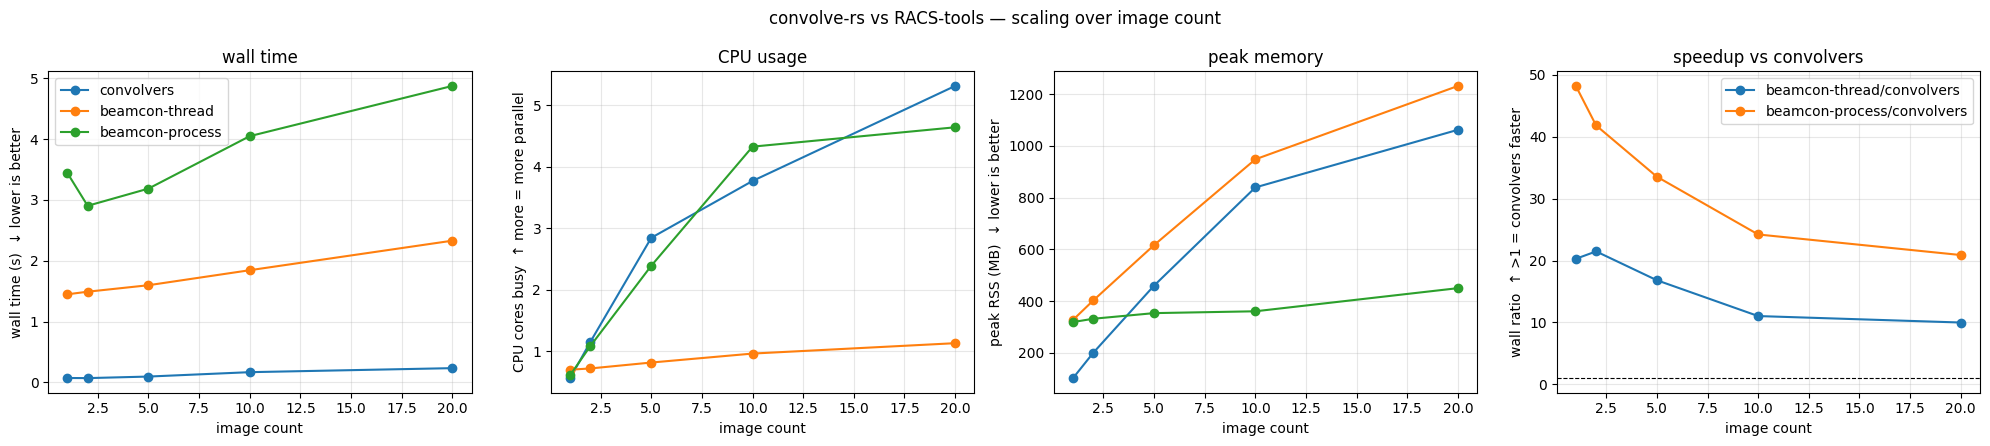

wrote bench_out/scaling_size.png


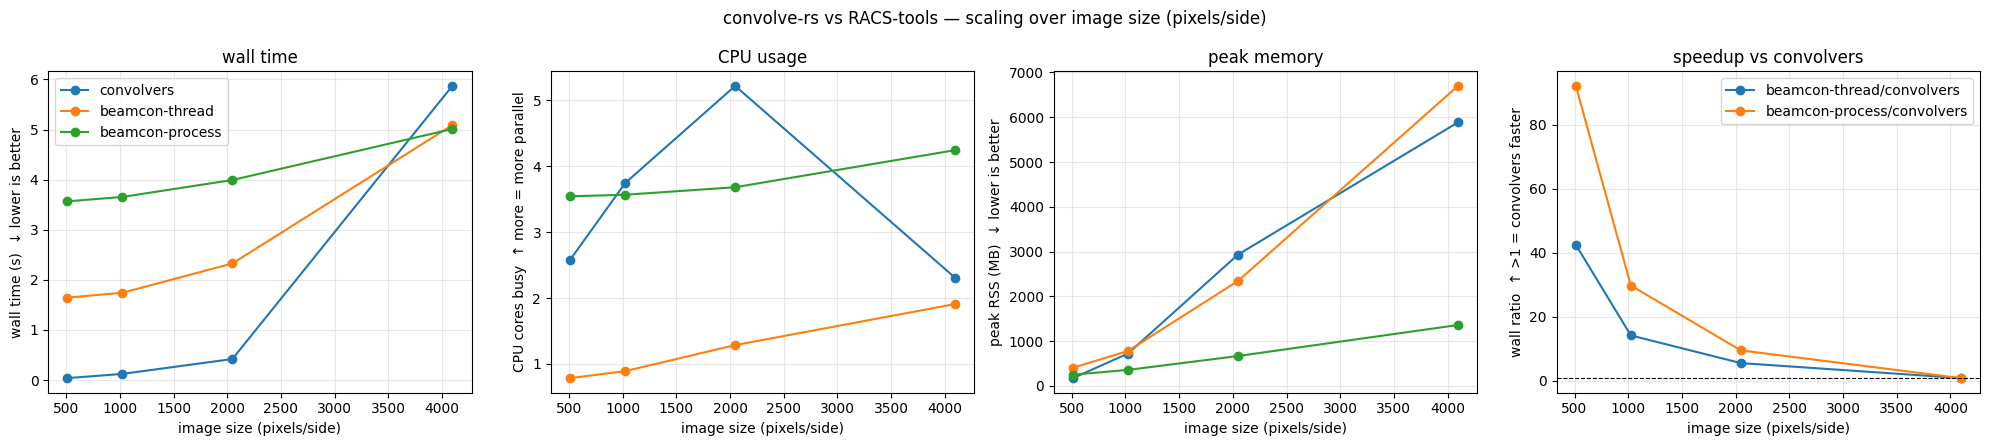

In [5]:
def plot_sweep(df: pd.DataFrame, axis_label: str, fname: str):
    # (column, axis label, title with direction-of-good note)
    metrics = [("wall", "wall time (s)  ↓ lower is better", "wall time"),
               ("cores", "CPU cores busy  ↑ more = more parallel", "CPU usage"),
               ("rss_mb", "peak RSS (MB)  ↓ lower is better", "peak memory")]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
    for ax, (col, ylabel, title) in zip(axes, metrics):
        for label in RUNNERS:
            sub = df[df.runner == label].sort_values("axis_value")
            ax.plot(sub.axis_value, sub[col], "o-", label=label)
        ax.set(xlabel=axis_label, ylabel=ylabel, title=title)
        ax.grid(alpha=0.3)
    axes[0].legend()

    # speedup of each beamcon runner vs convolvers (wall-time ratio)
    ax = axes[3]
    rs = df[df.runner == "convolvers"].set_index("axis_value").wall
    for label in RUNNERS:
        if RUNNERS[label] is None:
            continue
        sub = df[df.runner == label].set_index("axis_value").wall
        ratio = (sub / rs).sort_index()
        ax.plot(ratio.index, ratio.values, "o-", label=f"{label}/convolvers")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.set(xlabel=axis_label,
           ylabel="wall ratio  ↑ >1 = convolvers faster",
           title="speedup vs convolvers")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.suptitle(f"convolve-rs vs RACS-tools — scaling over {axis_label}")
    fig.tight_layout()
    out = WORK / fname
    fig.savefig(out, dpi=120, bbox_inches="tight")
    print("wrote", out)
    plt.show()

plot_sweep(sweep_n, "image count", "scaling_count.png")
plot_sweep(sweep_sz, "image size (pixels/side)", "scaling_size.png")

## Notes

- `cores busy` = (user + sys CPU seconds) / wall. >1 means real parallelism.
- convolvers parallelises across images; beamcon `thread` is GIL-bound (~1 core),
  `process` sidesteps the GIL at the cost of fork/serialisation startup.
- Accuracy: outputs agree to float32 round-off (max |Δ| ~1e-6), so speed/memory
  is an apples-to-apples comparison.